In [ ]:
# Clone YOLOv5
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

# Install requirements
!pip install -r requirements.txt

# Disable wandb (avoid login issues)
import os
os.environ['WANDB_DISABLED'] = 'true'

Cloning into 'yolov5'...
remote: Enumerating objects: 17889, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 17889 (delta 12), reused 4 (delta 4), pack-reused 17866 (from 4)
Receiving objects: 100% (17889/17889), 17.04 MiB | 19.63 MiB/s, done.
Resolving deltas: 100% (12173/12173), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0wyZ9c4UVXiCL3KKbovj")
project = rf.workspace("preeshas-workspace").project("railway-crack-detection-rlamm-rel8w")
version = project.version(4)
dataset = version.download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Railway-Crack-Detection-4 in yolov5pytorch:: 100%|██████████| 5107/5107 [00:00<00:00, 5788.66it/s]


In [ ]:
print(dataset.location)

/content/yolov5/Railway-Crack-Detection-4


In [ ]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17889, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 17889 (delta 34), reused 10 (delta 10), pack-reused 17836 (from 4)
Receiving objects: 100% (17889/17889), 17.05 MiB | 13.16 MiB/s, done.
Resolving deltas: 100% (12181/12181), done.


In [ ]:
%cd yolov5

/content/yolov5/yolov5


In [ ]:
!cat /content/yolov5/Railway-Crack-Detection-4/data.yaml

names:
- railway gap
nc: 1
roboflow:
  license: CC BY 4.0
  project: railway-crack-detection-rlamm-rel8w
  url: https://universe.roboflow.com/preeshas-workspace/railway-crack-detection-rlamm-rel8w/dataset/4
  version: 4
  workspace: preeshas-workspace
test: ../test/images
train: Railway-Crack-Detection-4/train/images
val: Railway-Crack-Detection-4/valid/images


In [ ]:
!nano /content/yolov5/Railway-Crack-Detection-4/data.yaml

/bin/bash: line 1: nano: command not found


In [ ]:
import yaml

file_path = "/content/yolov5/Railway-Crack-Detection-4/data.yaml"

with open(file_path) as f:
    data = yaml.safe_load(f)

data['train'] = '/content/yolov5/Railway-Crack-Detection-4/train/images'
data['val'] = '/content/yolov5/Railway-Crack-Detection-4/valid/images'

with open(file_path, 'w') as f:
    yaml.dump(data, f)

print("✅ Fixed data.yaml paths")

✅ Fixed data.yaml paths


In [ ]:
!python train.py \
--img 832 \
--batch 16 \
--epochs 150 \
--data /content/yolov5/Railway-Crack-Detection-4/data.yaml \
--weights yolov5m.pt \
--patience 30

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-26 08:12:16.109858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777191136.136880    9572 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777191136.144107    9572 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777191136.164874    9572 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777191136.164957    9572 computation_placer.cc:177] computation placer already registere

In [ ]:
!ls /content/yolov5/Railway-Crack-Detection-4/train/images | wc -l

2238


In [ ]:
!ls /content/yolov5/Railway-Crack-Detection-4/train/labels | wc -l

2238


In [ ]:
!cat /content/yolov5/Railway-Crack-Detection-4/data.yaml

names:
- railway gap
nc: 1
roboflow:
  license: CC BY 4.0
  project: railway-crack-detection-rlamm-rel8w
  url: https://universe.roboflow.com/preeshas-workspace/railway-crack-detection-rlamm-rel8w/dataset/4
  version: 4
  workspace: preeshas-workspace
test: ../test/images
train: /content/yolov5/Railway-Crack-Detection-4/train/images
val: /content/yolov5/Railway-Crack-Detection-4/valid/images


In [ ]:
import yaml

file_path = "/content/yolov5/Railway-Crack-Detection-4/data.yaml"

with open(file_path) as f:
    data = yaml.safe_load(f)

data['train'] = '/content/yolov5/Railway-Crack-Detection-4/train/images'
data['val'] = '/content/yolov5/Railway-Crack-Detection-4/valid/images'
data.pop('test', None)  # remove test if exists

with open(file_path, 'w') as f:
    yaml.dump(data, f)

print("✅ data.yaml fixed")

✅ data.yaml fixed


In [ ]:
!python train.py \
--img 832 \
--batch 16 \
--epochs 150 \
--data /content/yolov5/Railway-Crack-Detection-4/data.yaml \
--weights yolov5m.pt \
--patience 30 \
--workers 0

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-26 08:17:25.726470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777191446.035137   10834 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777191446.122796   10834 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777191446.594193   10834 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777191446.594257   10834 computation_placer.cc:177] computation placer already registere

In [ ]:
!python train.py \
--img 832 \
--batch 8 \
--epochs 100 \
--data /content/yolov5/Railway-Crack-Detection-4/data.yaml \
--weights yolov5m.pt \
--patience 50 \
--workers 0 \
--cache

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-26 08:21:12.846340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777191673.106503   11772 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777191673.176438   11772 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777191673.561362   11772 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777191673.561406   11772 computation_placer.cc:177] computation placer already registere

In [ ]:
!python train.py \
--img 640 \
--batch 4 \
--epochs 70 \
--data /content/yolov5/Railway-Crack-Detection-4/data.yaml \
--weights yolov5s.pt \
--workers 0 \
--cache ram \


wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-26 08:24:43.695070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777191883.720895   12709 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777191883.732532   12709 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777191883.758548   12709 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777191883.758612   12709 computation_placer.cc:177] computation placer already registere

In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [ ]:
!python train.py --img 640 --batch 4 --epochs 70 --data /content/yolov5/Railway-Crack-Detection-4/data.yaml --weights yolov5s.pt --workers 0 --cache ram

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-26 08:26:43.983458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777192004.007829   13201 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777192004.014724   13201 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777192004.032683   13201 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777192004.032758   13201 computation_placer.cc:177] computation placer already registere

In [ ]:
!python train.py --img 640 --batch 16 --epochs 80 --data /content/yolov5/Railway-Crack-Detection-4/data.yaml --weights yolov5s.pt --patience 50 --workers 0 --cache ram

Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
      43/79      4.59G     0.0259    0.00917          0         33        640:  51% 71/140 [00:27<00:25,  2.67it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      43/79      4.59G    0.02596   0.009191          0         32        640:  51% 72/140 [00:27<00:26,  2.61it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      43/79      4.59G    0.02597   0.009231          0         38        640:  52% 73/140 [00:28<00:25,  2.62it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.

In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --source /content/yolov5/Railway-Crack-Detection-4/test/images --conf 0.25 --img 832

detect: weights=['runs/train/exp/weights/best.pt'], source=/content/yolov5/Railway-Crack-Detection-4/test/images, data=data/coco128.yaml, imgsz=[832, 832], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/104 /content/yolov5/Railway-Crack-Detection-4/test/images/01560jfSanta_Mesa_PNR_Station_Pandacan_Railway_tracks_Manilafvf_10_jpg.rf.45b52bcec56be8d9be18217162eb0641.jpg: 640x832 1 railway gap, 33.7ms
image 2/104 /content/yolov5/Railway-Crack-Detection-4/test/images/13112

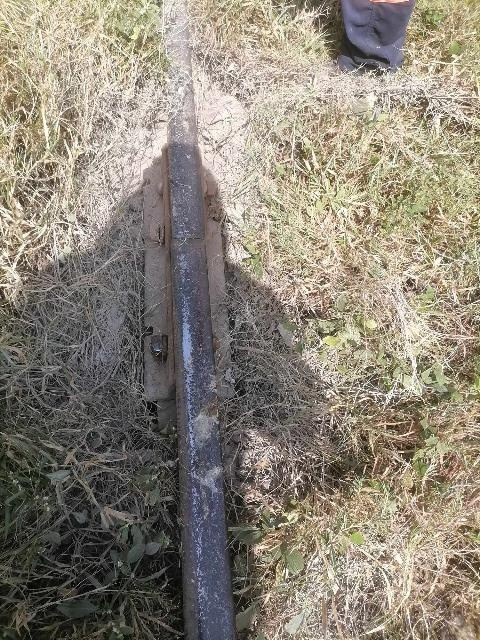

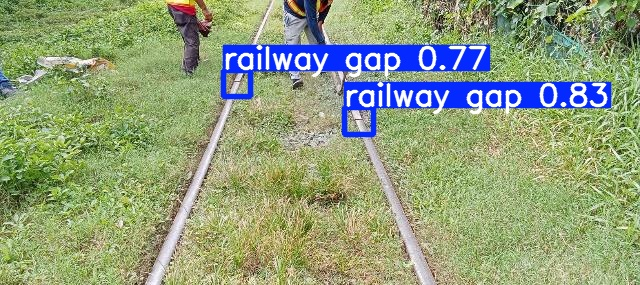

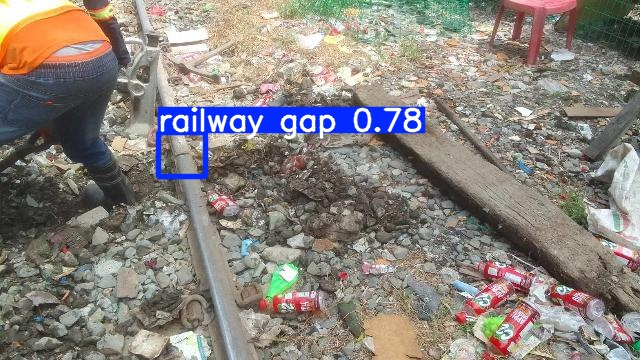

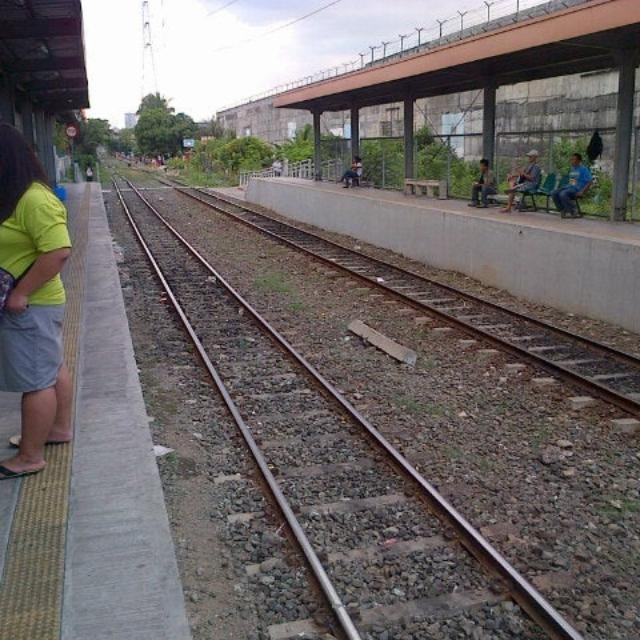

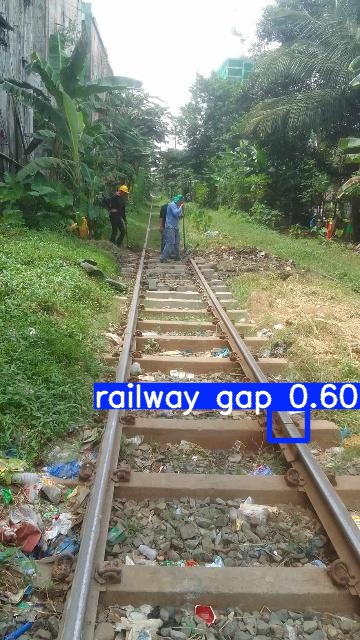

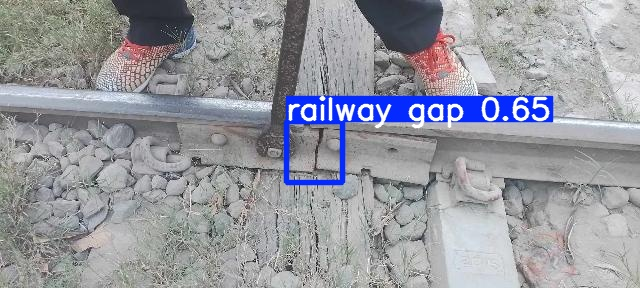

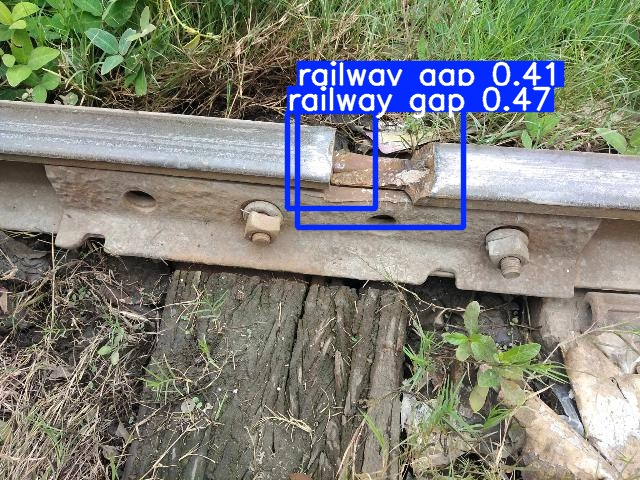

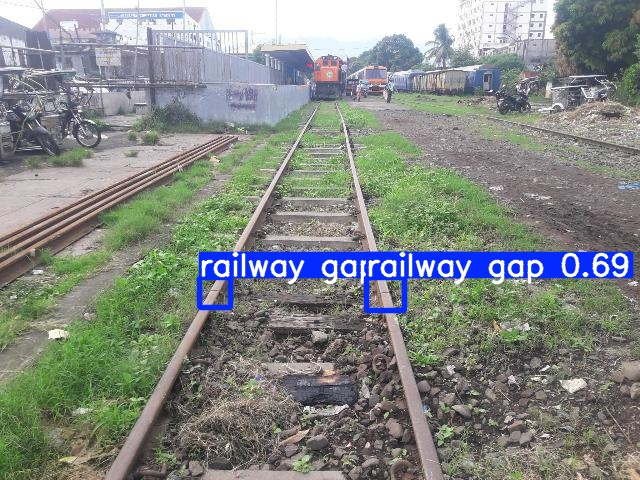

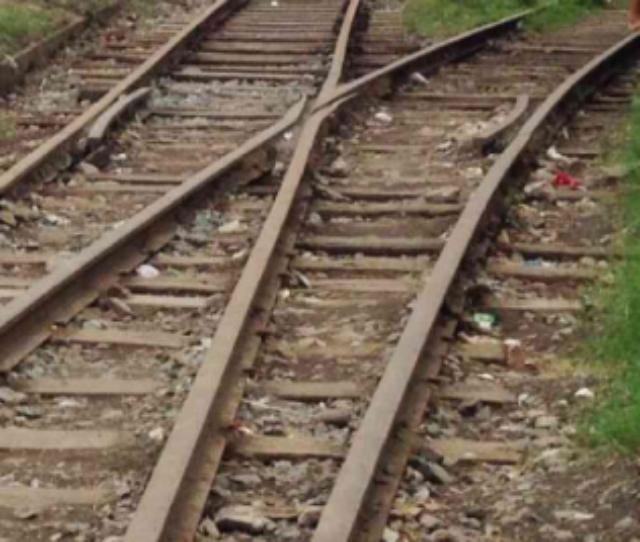

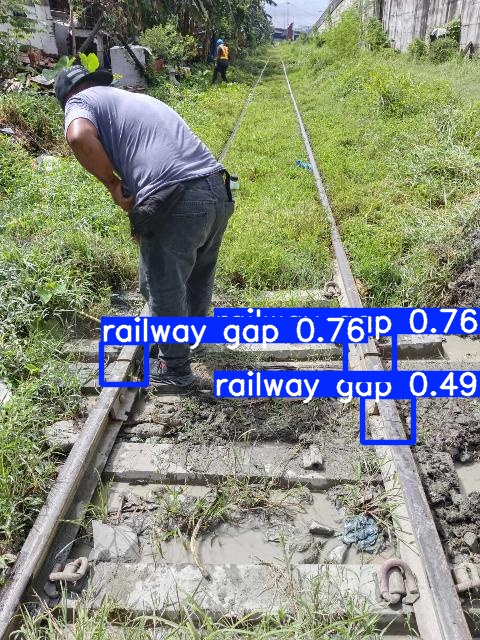

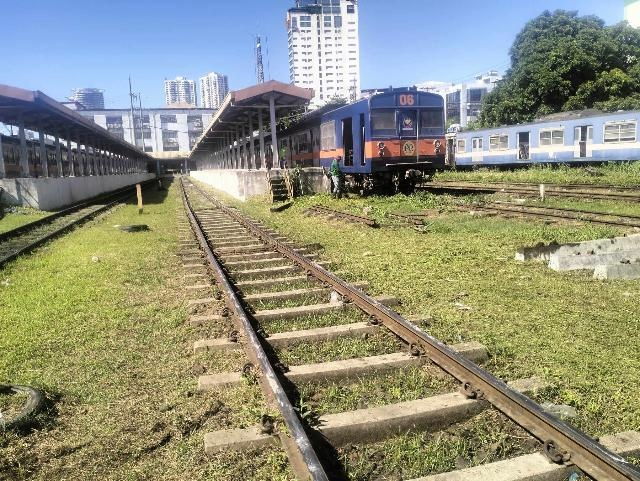

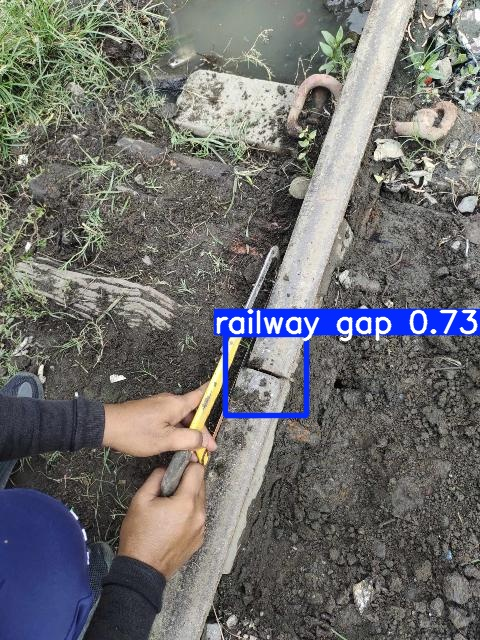

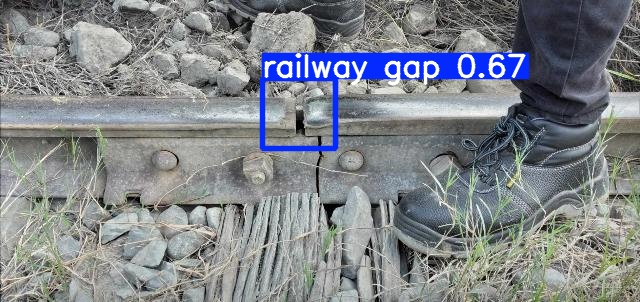

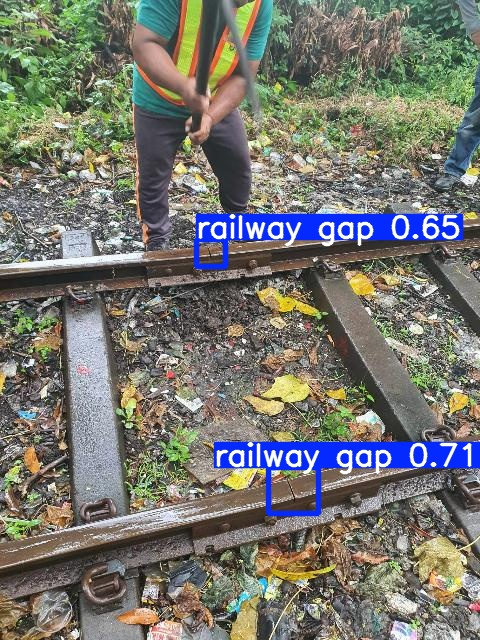

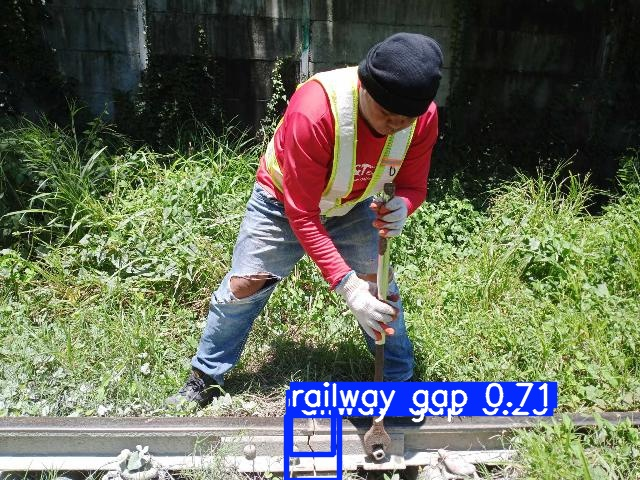

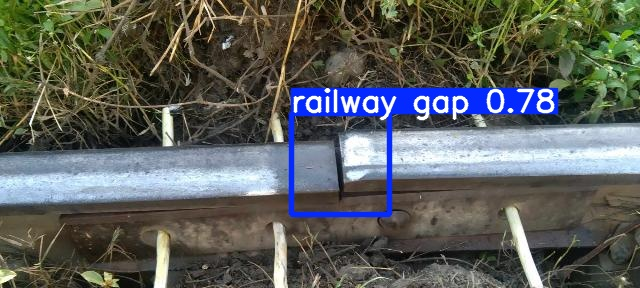

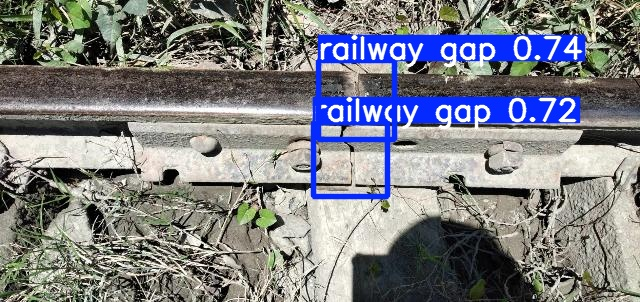

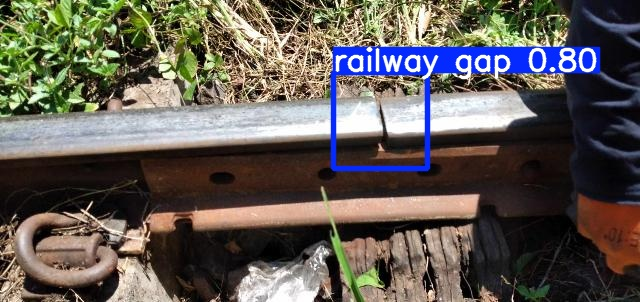

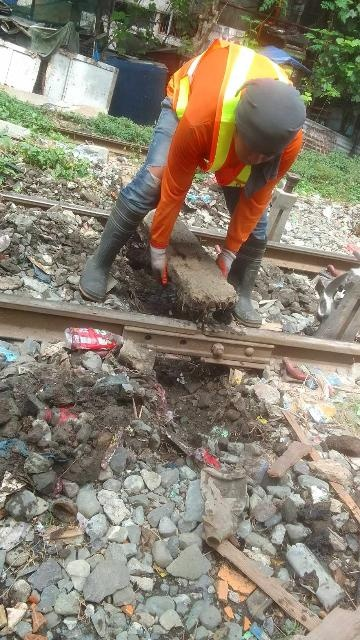

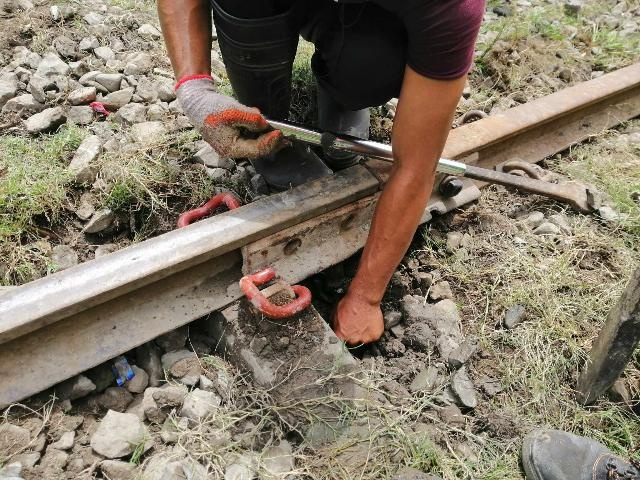

In [ ]:
from IPython.display import Image, display
import os

path = "runs/detect/exp"

for img in os.listdir(path)[:12]:
    display(Image(filename=os.path.join(path, img)))